# 02 - Análise Exploratória: Relação entre Chuva e Produção Agrícola no Sudeste

## Objetivo
Investigar como a precipitação total se relaciona com a produção agrícola das principais culturas do Sudeste brasileiro, com foco em padrões gerais e em uma análise mais detalhada da cultura da laranja.

## Dataset
- **Período**: 2013 a 2023
- **Região**: Sudeste brasileiro
- **Culturas**: Café, Cana-de-açúcar, Laranja e Milho
- **Variáveis analisadas**: Precipitação total (mm) e quantidade produzida (toneladas)

---


## 1. Carregando o dataset

Nesta etapa, o dataset é carregado e as primeiras linhas são visualizadas para confirmar se os dados foram importados corretamente.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#index_col=0 impede que o pandas crie uma coluna extra de índice
df = pd.read_csv('agro_clima.csv', index_col=0)
df.head()

,Região,Cultura,Quantidade_Produzida_Toneladas,CDD_dias_secos_consecutivos,Precipitacao_Total_mm,Temperatura_Media_C
Ano,,,,,,
2013,Sudeste,Café (em grão) Total,2595105.0,42.75,1873.10,25.53
2013,Sudeste,Cana-de-açúcar,514623424.0,42.75,1873.10,25.53
2013,Sudeste,Laranja,13989589.0,42.75,1873.10,25.53
2013,Sudeste,Milho (em grão),11932192.0,42.75,1873.10,25.53
2014,Sudeste,Café (em grão) Total,2445657.0,42.27,1758.39,25.70


## 2. Visualização Geral da Relação entre Chuva e Produção

O primeiro gráfico compara a **precipitação total** com a **quantidade produzida** para cada cultura. A ideia é observar se culturas diferentes apresentam comportamentos parecidos ou se cada uma responde de forma própria ao volume de chuva.


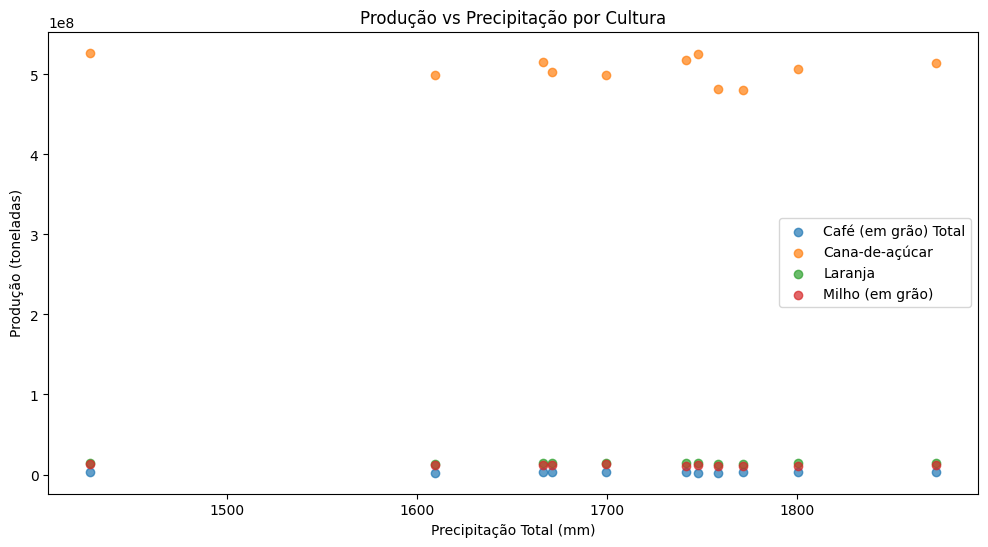

In [2]:
plt.figure(figsize=(12, 6))

culturas = df['Cultura'].unique()

for cultura in culturas:
    df_filtrado = df[df['Cultura'] == cultura]

    plt.scatter(
        df_filtrado['Precipitacao_Total_mm'],
        df_filtrado['Quantidade_Produzida_Toneladas'],
        label=cultura,
        alpha=0.7
    )

plt.xlabel("Precipitação Total (mm)")
plt.ylabel("Produção (toneladas)")
plt.title("Produção vs Precipitação por Cultura")

plt.legend()
plt.show()

## 3. Correlação entre Precipitação e Produção por Cultura

Além da visualização, a correlação ajuda a medir a direção da relação entre chuva e produção. Valores negativos indicam que, dentro dos dados analisados, maiores volumes de chuva aparecem associados a menores níveis de produção.


In [3]:
for cultura in culturas:
  df_culturas = df[df['Cultura'] == cultura]
  corr = df_culturas['Precipitacao_Total_mm'].corr(df_culturas['Quantidade_Produzida_Toneladas'], method='spearman')
  print(f'{cultura}: {corr:.2f}')

Café (em grão) Total: -0.15
Cana-de-açúcar: -0.26
Laranja: -0.35
Milho (em grão): -0.56


## 4. Recorte da Cultura da Laranja

Como a laranja apresenta uma relação negativa relevante entre chuva e produção, a análise passa a focar apenas nessa cultura. Esse recorte permite observar o comportamento com mais clareza, sem a interferência visual das demais culturas.


In [4]:
df_laranja = df[df['Cultura'] == 'Laranja'].sort_values('Precipitacao_Total_mm', ascending=False)
df_laranja.head()


,Região,Cultura,Quantidade_Produzida_Toneladas,CDD_dias_secos_consecutivos,Precipitacao_Total_mm,Temperatura_Media_C
Ano,,,,,,
2013,Sudeste,Laranja,13989589.0,42.75,1873.10,25.53
2018,Sudeste,Laranja,13906684.0,49.82,1800.40,25.57
2021,Sudeste,Laranja,13567947.0,57.65,1771.78,25.54
2014,Sudeste,Laranja,13345087.0,42.27,1758.39,25.70
2017,Sudeste,Laranja,14407113.0,61.46,1748.23,25.74


## 5. Produção da Laranja vs Precipitação

O gráfico abaixo mostra apenas os registros da **Laranja**, facilitando a leitura da relação entre volume de chuva e produção. Esse tipo de recorte é útil quando uma cultura apresenta padrão próprio dentro do conjunto de dados.


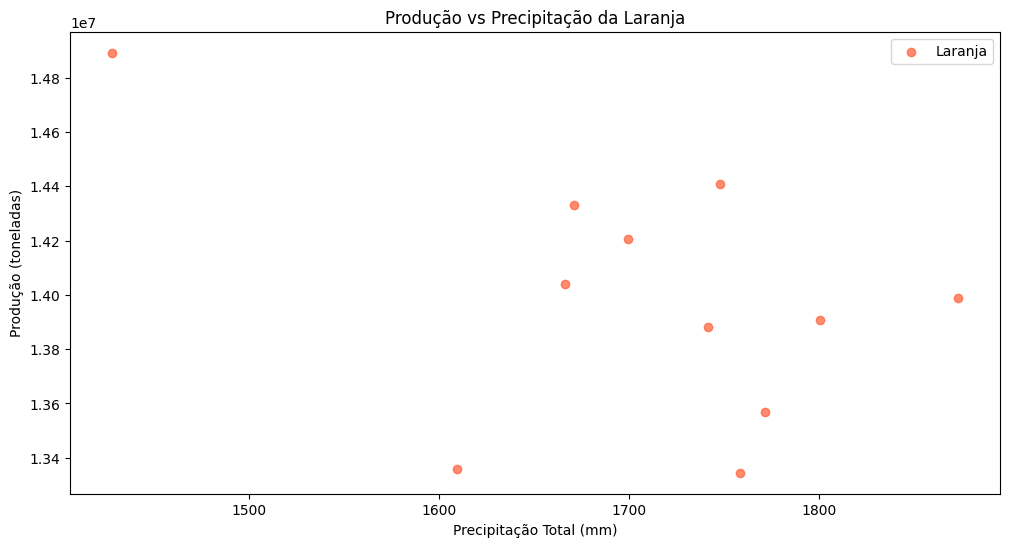

In [5]:
plt.figure(figsize=(12,6))
plt.scatter(df_laranja['Precipitacao_Total_mm'],
        df_laranja['Quantidade_Produzida_Toneladas'],
        color='#ff5c33',
        label='Laranja',
        alpha=0.7)

plt.xlabel("Precipitação Total (mm)")
plt.ylabel("Produção (toneladas)")
plt.title("Produção vs Precipitação da Laranja")

plt.legend()
plt.show()

## 6. Divisão da Precipitação em Faixas

Para transformar a análise visual em uma comparação mais direta, a precipitação da laranja é dividida em três faixas: baixa, média e alta. Assim, fica mais simples comparar a produção média em diferentes níveis de chuva.


In [6]:
xmin = df_laranja['Precipitacao_Total_mm'].min()
xmax = df_laranja['Precipitacao_Total_mm'].max()
print(f'max {xmax} / min {xmin}')
print(f'diferença min e max {xmax - xmin}')
print(f'divisão de cada terço {(xmax - xmin) / 3}')

max 1873.1 / min 1428.39
diferença min e max 444.7099999999998
divisão de cada terço 148.2366666666666


In [7]:
df_primeiro_terco = df_laranja.loc[df_laranja['Precipitacao_Total_mm'].between (1428.39, 1576.62)]
df_segundo_terco = df_laranja.loc[df_laranja['Precipitacao_Total_mm'].between (1576.62, 1724.85)]
df_terceiro_terco = df_laranja.loc[df_laranja['Precipitacao_Total_mm'].between (1724.85, 1873.1)]

## 7. Produção Média por Faixa de Chuva

Com as faixas definidas, a produção média é calculada para cada intervalo de precipitação. Essa comparação ajuda a verificar se existe queda ou aumento de produção conforme o volume de chuva muda.


In [8]:
media_1 = df_primeiro_terco['Quantidade_Produzida_Toneladas'].mean()
media_2 = df_segundo_terco['Quantidade_Produzida_Toneladas'].mean()
media_3 = df_terceiro_terco['Quantidade_Produzida_Toneladas'].mean()

print(f"Faixa baixa de chuva: {media_1:.2f}")
print(f"Faixa média de chuva: {media_2:.2f}")
print(f"Faixa alta de chuva: {media_3:.2f}")

Faixa baixa de chuva: 14891743.00
Faixa média de chuva: 13982946.00
Faixa alta de chuva: 13849683.00


## 8. Quantidade de Registros por Faixa

Antes de interpretar as médias, é importante verificar quantos registros existem em cada faixa. Uma faixa com poucos dados pode gerar uma média menos representativa e precisa ser lida com cuidado.


In [9]:
print(f"Faixa baixa: {len(df_primeiro_terco)} registros")
print(f"Faixa média: {len(df_segundo_terco)} registros")
print(f"Faixa alta: {len(df_terceiro_terco)} registros")

Faixa baixa: 1 registros
Faixa média: 4 registros
Faixa alta: 6 registros


## 9. Principais Insights da Análise Exploratória

### Relação Geral entre Chuva e Produção

As quatro culturas analisadas apresentaram **correlação negativa** entre precipitação total e produção agrícola. Isso sugere que, dentro deste recorte, mais chuva não esteve necessariamente associada a maior produção.

### Diferenças entre Culturas

O **Milho** apresentou a correlação negativa mais intensa (**-0,56**), seguido pela **Laranja** (**-0,35**), **Cana-de-açúcar** (**-0,26**) e **Café** (**-0,15**). Esse contraste indica que algumas culturas parecem mais sensíveis à variação de chuva do que outras.

### Foco na Laranja

Na cultura da **Laranja**, a precipitação variou de **1.428,39 mm** a **1.873,10 mm**, uma diferença de aproximadamente **444,71 mm**. Esse intervalo foi dividido em três faixas para comparar a produção média em cenários de chuva baixa, média e alta.

### Produção por Faixa de Chuva

A maior produção média da laranja aparece na faixa de **chuva baixa**, com cerca de **14.891.743 toneladas**. Em contraste, as faixas de chuva média e alta registram médias menores, próximas de **13,98 milhões** e **13,85 milhões de toneladas**.

### Cuidado na Interpretação

Apesar do padrão indicar queda da produção média conforme a chuva aumenta, a faixa de chuva baixa possui apenas **1 registro**. Por isso, o resultado deve ser tratado como um indício exploratório, não como uma conclusão definitiva.
